# Qubism visualizations

Qubism (or Qubism visualization) is a data visualization technique used primarily in quantum computing to represent the state of multiple qubits in a compact, grid-like format.

`The Core Idea`:

Instead of plotting quantum states in complex mathematical space, Qubism maps the amplitudes (probability weights) of a quantum system onto a 2D image where each pixel represents a specific combination of qubit states.


This note describes plotting functions `plot_schmidt` and `plot_qubism`, and additionally - `complex_array_to_rgb`, along with their applications.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import (Qobj, complex_array_to_rgb, jmat, ket, plot_qubism, plot_schmidt,
                    qeye, sigmax, sigmay, sigmaz, tensor)

%matplotlib inline

## Colors

In quantum mechanics, complex numbers are as natual as real numbers.

Before going into details of particular plots, we show how `complex_array_to_rgb` maps  $z=x+iy$ into colors. There are two variants, `theme='light'` and `theme='dark'`. For both, we use hue for phase, with red for positive numbers and aqua for negative.

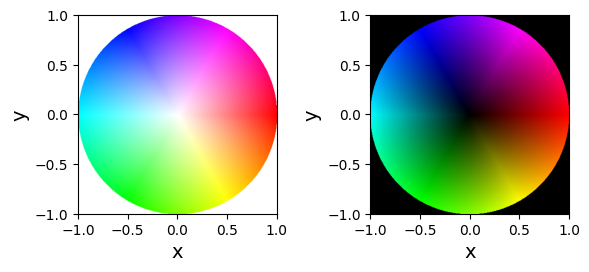

In [4]:
compl_circ = np.array(
    [
        [(x + 1j * y) if x ** 2 + y ** 2 <= 1 else 0j
            for x in np.arange(-1, 1, 0.005)]
        for y in np.arange(-1, 1, 0.005)
    ]
)

fig = plt.figure(figsize=(6, 3))
for i, theme in enumerate(["light", "dark"]):
    ax = plt.subplot(1, 2 , i + 1)
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)
    ax.imshow(
        complex_array_to_rgb(compl_circ, rmax=1, theme=theme),
        extent=(-1, 1, -1, 1)
    )
plt.tight_layout()

## Schmidt plot

Arguably, the easiest way to show entanglement is to plot a wavefunction against two variables. If the plot is a product of them, the state is a product state. If not - it is entangled.

A **Schmidt plot** is a way to visualize a quantum wavefunction by arranging its amplitudes as a matrix instead of a vector. This makes it easy to see whether a state is **entangled** or **separable** (a product state) at a glance.

`The Key Idea`:

- "If the plot is a product of them, the state is a product state. If not — it is entangled."
- This refers to **Schmidt decomposition** — a mathematical way to write any bipartite quantum state as a sum of products of states from each subsystem. If there's only **one term** in that sum, the state is separable. If there are **multiple terms**, it's entangled.

As writing a wavefunction as a matrix $|\psi \rangle _{ij}$ is the the crucial step in [Schmidt decomposition](https://en.wikipedia.org/wiki/Schmidt_decomposition"), we call such plots Schmidt plots.

Let us consider two states:

- entangled: singlet state $|\psi \rangle = \frac{|01\rangle - |10 \rangle}{\sqrt2}$
- product $\frac{|01\rangle - |00\rangle}{\sqrt2}$

They may look seamingly similar, but the later can be decomposed into a product $\frac{|0\rangle (|1\rangle - |0\rangle)}{\sqrt2}$